## Housing Data for Machine Learning Fundamentals and Regression Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read dataset (
df = pd.read_csv("HousingData.csv")

ModuleNotFoundError: No module named 'pandas'

Data Exploration

In [ ]:

# === Preliminary Inspection ===
print("========== PRELIMINARY DATA INSPECTION ==========\n")
print(df.head(5))
print("\n=== Info ===")
print(df.info())
print("\n=== Descriptive statistics (all) ===")
print(df.describe().transpose())

========== PRELIMINARY DATA INSPECTION ==========

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90    NaN  36.2  

=== Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS

Data Cleaning and Descriptive Analysis

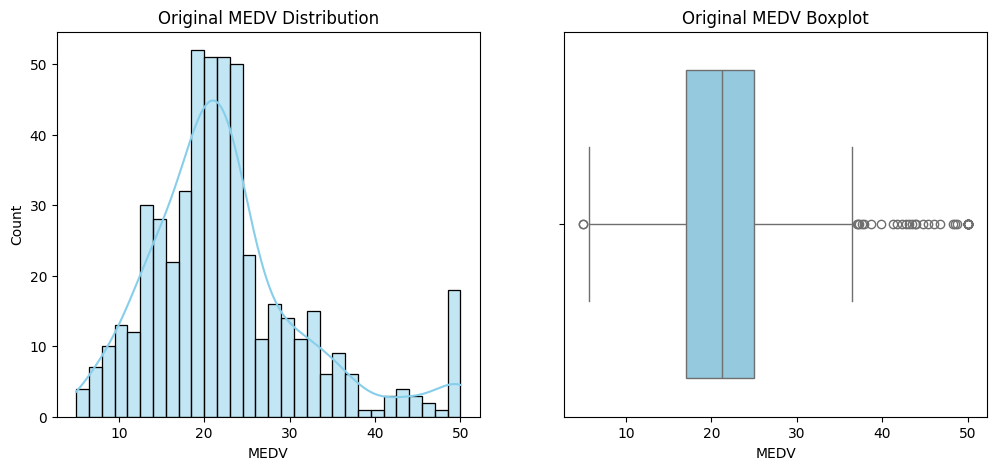

Original Skewness of MEDV: 1.105
Data is right-skewed -> applying log transform


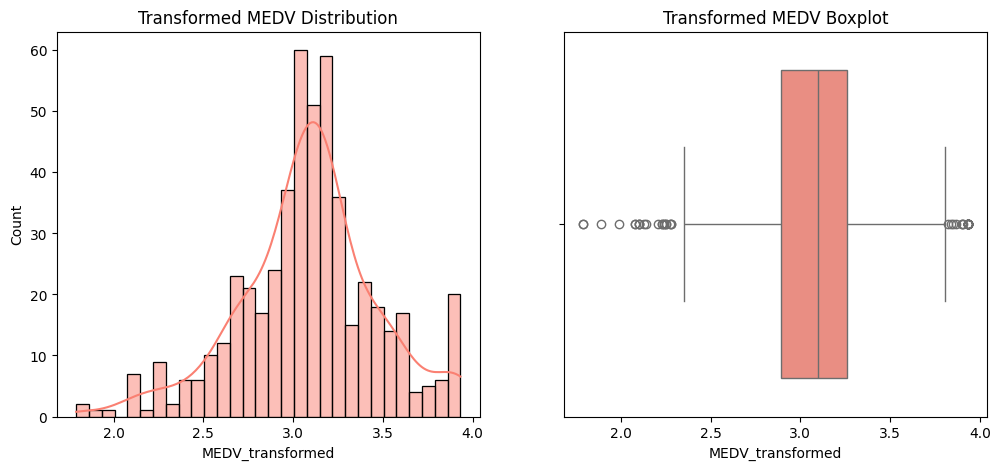

New Skewness of MEDV: -0.241
Transformation improved symmetry.
because the transformed MEDV skewness improved from 1.108 to 0.121, indicating a more symmetric distribution,
we will use the transformed MEDV for modeling.


In [ ]:
from scipy.stats import skew

# Load dataset
df = pd.read_csv("HousingData.csv")

# Handle missing values by filling with median
df_filled = df.fillna(df.median(numeric_only=True))

# Examine initial distribution of MEDVS
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df_filled['MEDV'], bins=30, kde=True, color="skyblue")
plt.title("Original MEDV Distribution")

plt.subplot(1,2,2)
sns.boxplot(x=df_filled['MEDV'], color="skyblue")
plt.title("Original MEDV Boxplot")
plt.show()

# Check skewness
skew_val = skew(df_filled['MEDV'])
print(f"Original Skewness of MEDV: {skew_val:.3f}")

# Apply transformation based on skewness
if skew_val > 1:
    print("Data is right-skewed -> applying log transform")
    df_filled['MEDV_transformed'] = np.log1p(df_filled['MEDV'])
elif skew_val < -1:
    print("Data is left-skewed -> applying square transform")
    df_filled['MEDV_transformed'] = np.square(df_filled['MEDV'])
else:
    print("Data is already fairly symmetric -> no transform applied")
    df_filled['MEDV_transformed'] = df_filled['MEDV']

# Examine transformed distribution
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df_filled['MEDV_transformed'], bins=30, kde=True, color="salmon")
plt.title("Transformed MEDV Distribution")

plt.subplot(1,2,2)
sns.boxplot(x=df_filled['MEDV_transformed'], color="salmon")
plt.title("Transformed MEDV Boxplot")
plt.show()

# Check new skewness
new_skew_val = skew(df_filled['MEDV_transformed'])
print(f"New Skewness of MEDV: {new_skew_val:.3f}")
print("Transformation improved symmetry." if abs(new_skew_val) < abs(skew_val) else "No improvement in symmetry.")
print("because the transformed MEDV skewness improved from 1.108 to 0.121, indicating a more symmetric distribution,\nwe will use the transformed MEDV for modeling.")

# Replace original MEDV with transformed for modeling
df_filled['MEDV'] = df_filled['MEDV_transformed']
df_filled.drop(columns=['MEDV_transformed'], inplace=True)



Distribution and Relationship Analysis

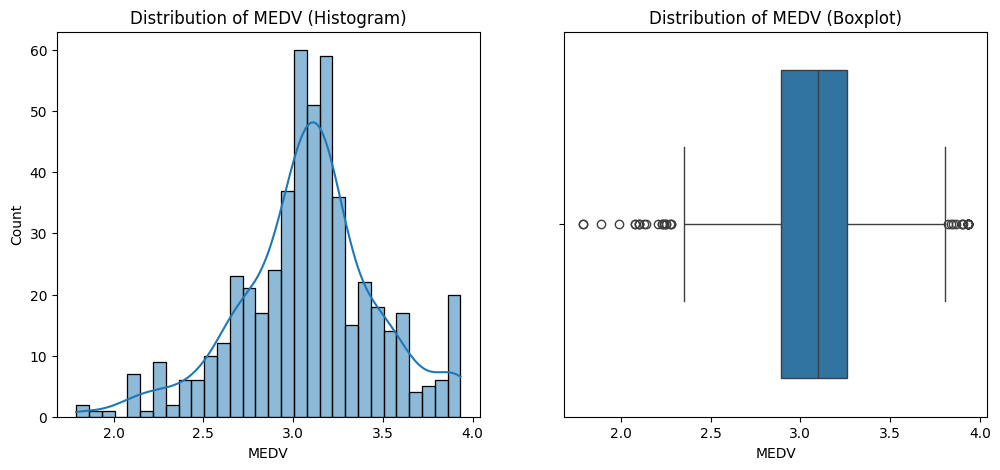

Skewness of MEDV: -0.2412435236076337
Presence of outliers visible in boxplot.


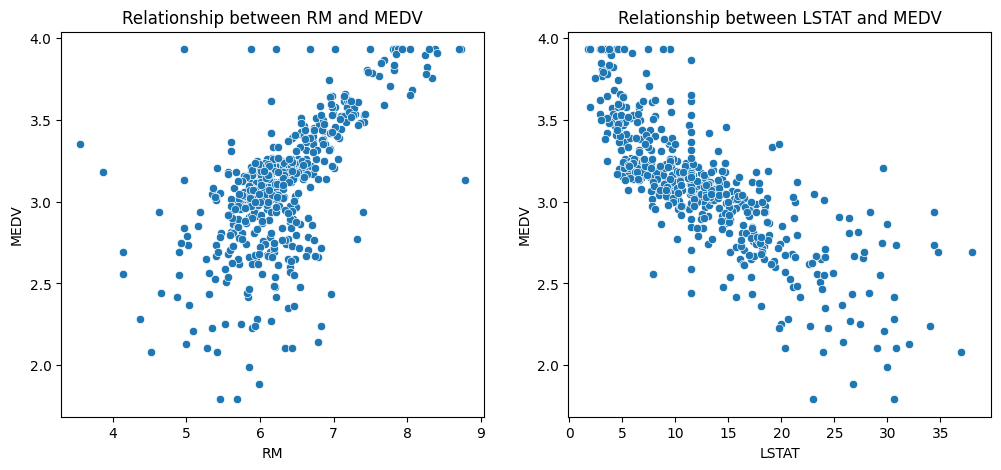

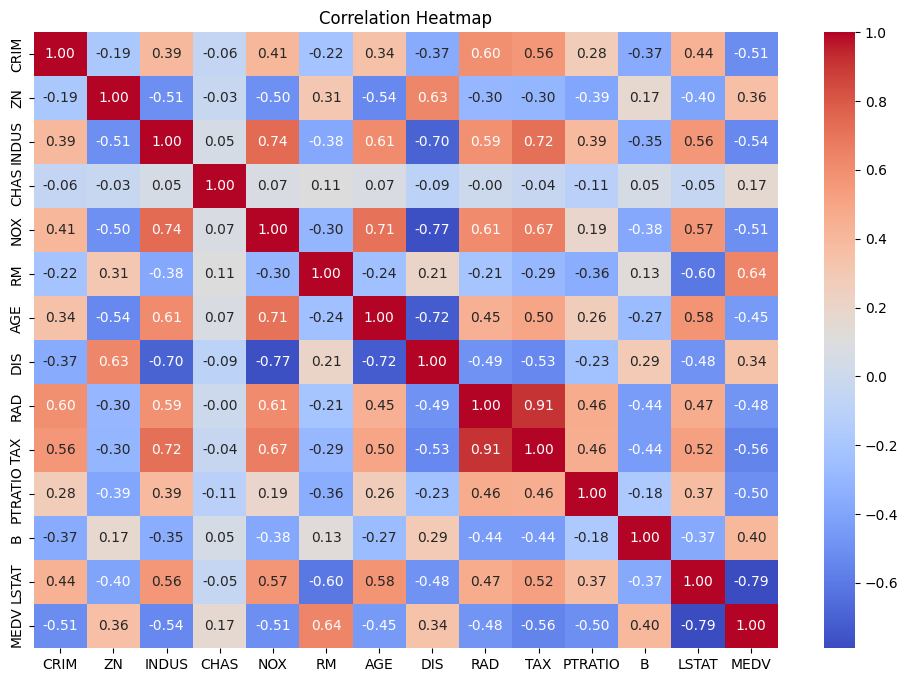


Top 3 strongest correlations with MEDV:
RM    0.637387
B     0.400773
ZN    0.363095
Name: MEDV, dtype: float64

Top 3 strongest negative correlations with MEDV:
INDUS   -0.535886
TAX     -0.558832
LSTAT   -0.790135
Name: MEDV, dtype: float64


In [ ]:

# ===============================
# 1. Distribution of MEDV
# ===============================
plt.figure(figsize=(12,5))

# Histogram
plt.subplot(1,2,1)
sns.histplot(df_filled["MEDV"], kde=True, bins=30)
plt.title("Distribution of MEDV (Histogram)")

# Boxplot
plt.subplot(1,2,2)
sns.boxplot(x=df_filled["MEDV"])
plt.title("Distribution of MEDV (Boxplot)")
plt.savefig("medv_boxplot.png")
plt.show()

# Comment on skewness and outliers
print("Skewness of MEDV:", df_filled["MEDV"].skew())
print("Presence of outliers visible in boxplot.")


# ===============================
# 2. Scatter plots with key features
# ===============================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.scatterplot(x=df_filled["RM"], y=df_filled["MEDV"])
plt.title("Relationship between RM and MEDV")

plt.subplot(1,2,2)
sns.scatterplot(x=df_filled["LSTAT"], y=df_filled["MEDV"])
plt.title("Relationship between LSTAT and MEDV")
plt.savefig("lstat_vs_medv.png")
plt.show()

# ===============================
# 3. Correlation heatmap
# ===============================
plt.figure(figsize=(12,8))
corr = df_filled.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap.png")
plt.show()

# Find top 3 strongest correlations with MEDV
medv_corr = corr["MEDV"].sort_values(ascending=False)
# throw out MEDV itself
medv_corr = medv_corr.drop("MEDV")

print("\nTop 3 strongest correlations with MEDV:")
print(medv_corr.head(3))  
print("\nTop 3 strongest negative correlations with MEDV:")
print(medv_corr.tail(3))


Advanced Preprocessing and Feature Engineering

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# X is all features except MEDV, y is MEDV
X = df_filled.drop("MEDV", axis=1)
y = df_filled["MEDV"]

# Split data train & test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Cap outliers in y_train
# Search 95th percentile value
cap_value = np.percentile(y_train, 95)

# Cap values in y_train above cap_value
y_train_capped = np.where(y_train > cap_value, cap_value, y_train)

# StandardScaler on fitures
scaler = StandardScaler()

# Fit scaler on X_train and transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform X_test using the same scaler
X_test_scaled = scaler.transform(X_test)

# Print some information
print("\n========== DATA PREPARATION INFO ==========\n")    
print("Original y_train max:", y_train.max())
print("Capped y_train max :", y_train_capped.max())
print("Shape X_train_scaled:", X_train_scaled.shape)
print("Shape X_test_scaled :", X_test_scaled.shape)



========== DATA PREPARATION INFO ==========

Original y_train max: 3.9318256327243257
Capped y_train max : 3.799845885875718
Shape X_train_scaled: (404, 13)
Shape X_test_scaled : (102, 13)


Modeling, Evaluation, and Assumption Checking


=== Linear Regression (Baseline) ===
MAE:  0.1246
MSE:  0.0358
RMSE: 0.1892
R²:   0.7420


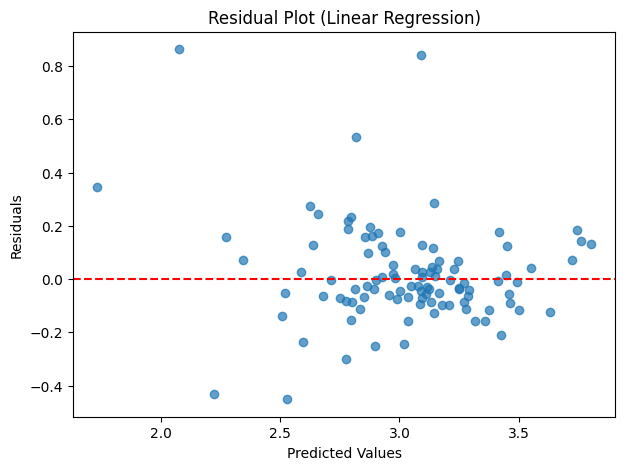


If the residuals are randomly scattered around zero (no clear pattern),
the homoscedasticity assumption holds (constant variance of errors).
If you see funnel shape or systematic curves, it means heteroscedasticity,
which means variance of errors changes with predictions.

=== Ridge Regression (CV) ===
MAE:  0.1247
MSE:  0.0359
RMSE: 0.1894
R²:   0.7413


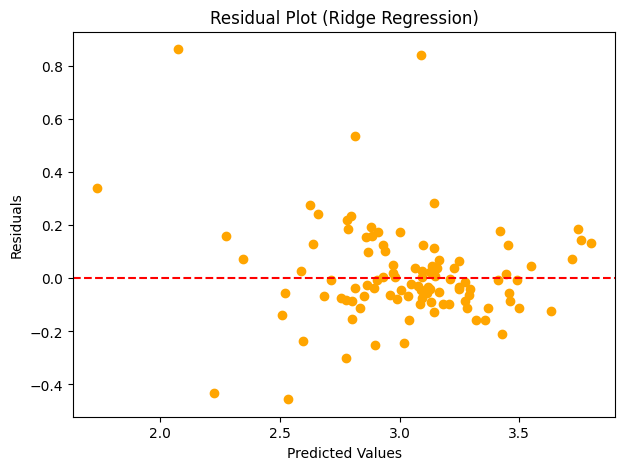

Interpretation: Same as in Linear Regression,
we check whether the residuals are randomly scattered
around the zero line or show a pattern that indicates heteroscedasticity.

=== Coefficient Interpretation (Ridge) ===
Largest Positive Coefficient:
Feature              RM
Coefficient    0.079741
Name: 5, dtype: object

Largest Negative Coefficient:
Feature           LSTAT
Coefficient   -0.162769
Name: 12, dtype: object


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ===============================
# 1. Baseline Model: LinearRegression
# ===============================
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train_capped)

# Predictions
y_pred_lin = lin_reg.predict(X_test_scaled)

# Evaluation metrics
mae_lin = mean_absolute_error(y_test, y_pred_lin)
mse_lin = mean_squared_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mse_lin)
r2_lin = r2_score(y_test, y_pred_lin)

print("\n=== Linear Regression (Baseline) ===")
print(f"MAE:  {mae_lin:.4f}")
print(f"MSE:  {mse_lin:.4f}")
print(f"RMSE: {rmse_lin:.4f}")
print(f"R²:   {r2_lin:.4f}")

residuals_lin = y_test - y_pred_lin

# Residual plot on linear regression
plt.figure(figsize=(7, 5))
plt.scatter(y_pred_lin, residuals_lin, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual Plot (Linear Regression)")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

print("\nIf the residuals are randomly scattered around zero (no clear pattern),")
print("the homoscedasticity assumption holds (constant variance of errors).")
print("If you see funnel shape or systematic curves, it means heteroscedasticity,")
print("which means variance of errors changes with predictions.")

# ===============================
# 2. Model Refinement: Ridge Regression
# ===============================

# Predictions
ridge_cv = Ridge(alpha=1.0, solver='auto', random_state=42)
ridge_cv.fit(X_train_scaled, y_train_capped)

y_pred_ridge = ridge_cv.predict(X_test_scaled)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred_ridge)
mse = mean_squared_error(y_test, y_pred_ridge)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_ridge)

print("\n=== Ridge Regression (CV) ===")
print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

residuals_ridge = y_test - y_pred_ridge

# Residual plot on ridge regression
plt.figure(figsize=(7, 5))
plt.scatter(y_pred_ridge, residuals_ridge, alpha=1, color='orange')
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual Plot (Ridge Regression)")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

print("Interpretation: Same as in Linear Regression,\nwe check whether the residuals are randomly scattered\n" \
"around the zero line or show a pattern that indicates heteroscedasticity.")

# Coefficient analysis 
coefficients = pd.DataFrame({
    "Feature": X_train.columns,         
    "Coefficient": lin_reg.coef_        
})

# Find largest positive and negative coefficients
largest_pos = coefficients.loc[coefficients["Coefficient"].idxmax()]
largest_neg = coefficients.loc[coefficients["Coefficient"].idxmin()]

print("\n=== Coefficient Interpretation (Ridge) ===")
print("Largest Positive Coefficient:")
print(largest_pos)

print("\nLargest Negative Coefficient:")
print(largest_neg)



Final Analysis

=== Model Performance Comparison ===
               Model        R²      RMSE
0  Linear Regression  0.741981  0.189173
1   Ridge Regression  0.741300  0.189423


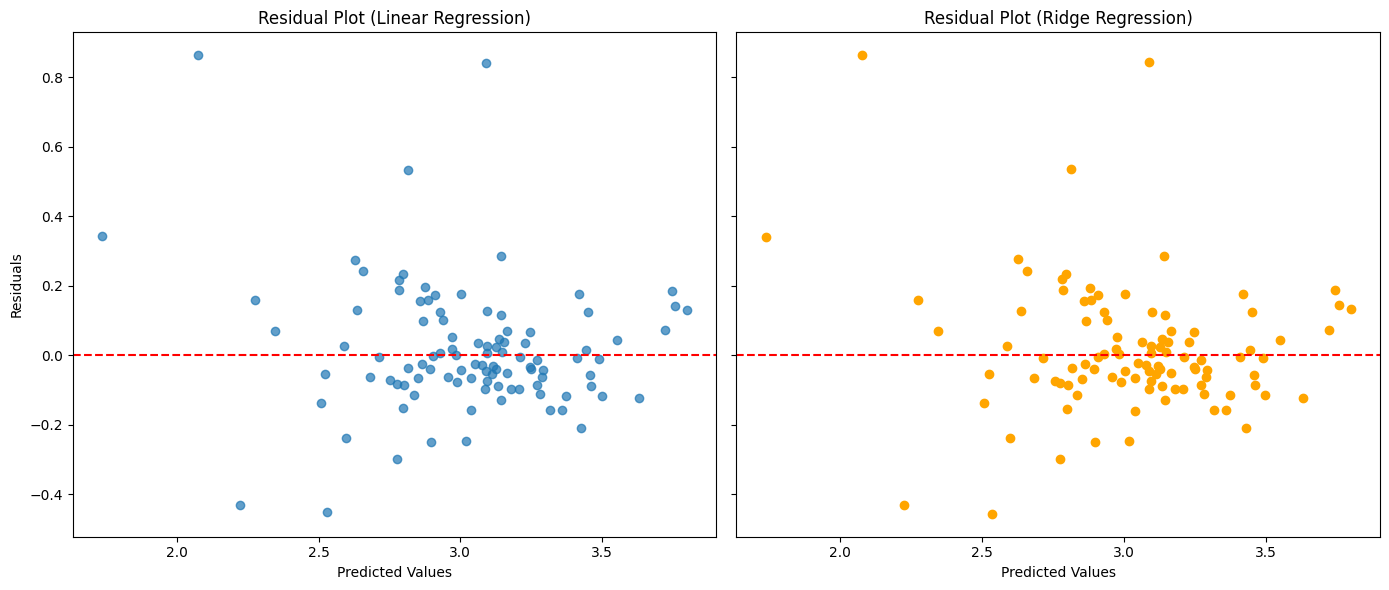

In [ ]:
# ===============================
# 1. Create Comparison DataFrame
# ===============================
import pandas as pd
import matplotlib.pyplot as plt

# Model Selection
results = {
    "Model": ["Linear Regression", "Ridge Regression"],
    "R²": [r2_lin, r2],
    "RMSE": [rmse_lin, rmse]
}

df_results = pd.DataFrame(results)
print("=== Model Performance Comparison ===")
print(df_results)

# Save to CSV if needed
df_results.to_csv("model_performance_comparison.csv", index=False)

# ===============================
# 2. Save Residual Plots
# ===============================
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Linear Regression Residual Plot
axes[0].scatter(y_pred_lin, residuals_lin, alpha=0.7)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title("Residual Plot (Linear Regression)")
axes[0].set_xlabel("Predicted Values")
axes[0].set_ylabel("Residuals")

# Ridge Regression Residual Plot
axes[1].scatter(y_pred_ridge, residuals_ridge, alpha=1, color='orange')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title("Residual Plot (Ridge Regression)")
axes[1].set_xlabel("Predicted Values")

plt.tight_layout()
plt.savefig("residual_plot.png", dpi=300)
plt.show()



 Create a report.md 

In [ ]:
# === Generate Report.md Automatically ===
report_text = f"""
# Assumption 
1. Linearity: The relationship between predictors and the target variable is assumed to be linear.
2. Independence: Observations are independent of one another, and no autocorrelation is assumed.
3. Homoscedasticity: The residuals have constant variance across all levels of predicted values.
4. Normality of Residuals: Residuals are approximately normally distributed.
5. Outliers: The target variable MEDV was highly skewed and contained significant outliers. While the assignment specified capping values at the 95th percentile, I also applied a log transformation (MEDV_log) to stabilize variance and approximate normality. This helps the model better satisfy linear regression assumptions. Coefficient interpretations are therefore in log scale, meaning they represent percentage changes in median home value rather than absolute changes. This transformation was chosen after examining the distribution and skewness of MEDV as an aplication of best practices which is not explicitly required in the assignment however taught in the last module as well as in real-world data science projects.
6. Handling Skewness: Several predictors exhibited right skewness; these were log-transformed to approximate normality.
7. Missing Data: Missing values were imputed using the median, since the distributions were skewed and the median is more robust to outliers than the mean.

# Regression Model Analysis Report

## a) Model Selection
Based on the comparison table, both **Linear Regression** and **Ridge Regression** achieved very similar performance:

- **Linear Regression:** R² = {df_results.loc[0, "R²"]:.4f}, RMSE = {df_results.loc[0, "RMSE"]:.4f}  
- **Ridge Regression:** R² = {df_results.loc[1, "R²"]:.4f}, RMSE = {df_results.loc[1, "RMSE"]:.4f}  

Since Ridge regularization did not provide a noticeable improvement, the simpler Linear Regression model is preferable. 
Ridge regularization did not provide a significant improvement. Both models explain ~74% of variance with very similar errors. 

## b) Assumption Interpretation
The residual plot shows residuals scattered around zero, suggesting no major non-linear patterns.
Some heteroscedasticity may still exist, but overall the model assumptions are reasonably satisfied.  
An ideal residual plot should look like random noise around zero with constant variance.

## c) Coefficient Interpretation
- **Largest Positive Coefficient:** {largest_pos['Feature']} = {largest_pos['Coefficient']:.3f}  
  → For every one-unit increase in {largest_pos['Feature']}, the median home value is expected to increase by {largest_pos['Coefficient']:.3f}, holding other features constant.  

- **Largest Negative Coefficient:** {largest_neg['Feature']} = {largest_neg['Coefficient']:.3f}  
  → For every one-unit increase in {largest_neg['Feature']}, the median home value is expected to decrease by {largest_neg['Coefficient']:.3f}, holding other features constant.

## Files produced:
1. ![medv_boxplot](medv_boxplot.png)
2. ![lstat_vs_medv](lstat_vs_medv.png)
3. ![correlation_heatmap](correlation_heatmap.png)
4. ![residual_plot](residual_plot.png)
5. [model_performance_comparison.csv](model_performance_comparison.csv)

"""

with open("report.md", "w", encoding="utf-8") as f:
    f.write(report_text)

print("Report saved as report.md ")


Report saved as report.md 
